# Final Assignment - Part 2

### Assignment Instructions

#### Part 2   |   Advanced Difficulty Level

In this second part, you will be working with a datasets containing information on indian startups' funding, including the startup's details, the funding it received, and the investors' information. 

In the usual `data` folder, you will find the following three datasets, including data from 2019, 2020 and 2021: 

- `startup_funding2019.csv`
- `startup_funding2020.csv`
- `startup_funding2021.csv`

At [this link](https://www.kaggle.com/datasets/omkargowda/indian-startups-funding-data?select=startup_funding2019.csv) you can find the source of the original data (Kaggle) as well as more information on its composition *(note: the files in the data folder are slightly different from the originals)*.

1. Using a **for loop**, load all three .csv files in a temporary DataFrame called `df_tmp` and, at each cycle, add a new column named `Year` that includes the year of that csv file to the temporary table and append it to a final DataFrame named `fnd`. Your final `fnd` DataFrame should include the contents from all three csv files stacked one on top of the other. 

    What is the **shape** of the `fnd` DataFrame? 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

fnd = pd.DataFrame({})
years_list = ['2019', '2020', '2021']

for y in years_list:
    df_temp = pd.read_csv(f'data/startup_funding{y}.csv')
    print(f'size of the dataframe for year {y}: {len(df_temp)}')
    df_temp['Year'] = y
    fnd = pd.concat([fnd, df_temp], ignore_index=True)

fnd.head(10)

size of the dataframe for year 2019: 89
size of the dataframe for year 2020: 1052
size of the dataframe for year 2021: 1202


,Company/Brand,Founded,HeadQuarter,Sector,What it does,Founders,Investor,Amount($),Stage,Year
0,Bombay Shaving,NaN,NaN,Ecommerce,Provides a range of male grooming products,Shantanu Deshpande,Sixth Sense Ventures,"$6,300,000",NaN,2019
1,Ruangguru,2014.0,Mumbai,Edtech,A learning platform that provides topic-based ...,"Adamas Belva Syah Devara, Iman Usman.",General Atlantic,"$150,000,000",Series C,2019
2,Eduisfun,NaN,Mumbai,Edtech,It aims to make learning fun via games.,Jatin Solanki,"Deepak Parekh, Amitabh Bachchan, Piyush Pandey","$28,000,000",Fresh funding,2019
3,HomeLane,2014.0,Chennai,Interior design,Provides interior designing solutions,"Srikanth Iyer, Rama Harinath","Evolvence India Fund (EIF), Pidilite Group, FJ...","$30,000,000",Series D,2019
4,Nu Genes,2004.0,Telangana,AgriTech,"It is a seed company engaged in production, pr...",Narayana Reddy Punyala,Innovation in Food and Agriculture (IFA),"$6,000,000",NaN,2019
5,FlytBase,NaN,Pune,Technology,A drone automation platform,Nitin Gupta,Undisclosed,Undisclosed,NaN,2019
6,Finly,NaN,Bangalore,SaaS,It builds software products that makes work si...,"Vivek AG, Veekshith C Rai","Social Capital, AngelList India, Gemba Capital...",Undisclosed,NaN,2019
7,Kratikal,2013.0,Noida,Technology,It is a product-based cybersecurity solutions ...,"Pavan Kushwaha, Paratosh Bansal, Dip Jung Thapa","Gilda VC, Art Venture, Rajeev Chitrabhanu.","$1,000,000",Pre series A,2019
8,Quantiphi,NaN,NaN,AI & Tech,It is an AI and big data services company prov...,Renuka Ramnath,Multiples Alternate Asset Management,"$20,000,000",Series A,2019
9,Lenskart,2010.0,Delhi,E-commerce,It is a eyewear company,"Peyush Bansal, Amit Chaudhary, Sumeet Kapahi",SoftBank,"$275,000,000",Series G,2019


In [2]:
# check if I loaded the correct csv
print(f'rows in fnd: {len(fnd)}')

check_sum = 0
for y in years_list:
    print(f'rows in {y}: {len(fnd[fnd["Year"] == y])}')
    check_sum += len(fnd[fnd["Year"] == y])

print(f'check the sum: {check_sum}')

rows in fnd: 2343
rows in 2019: 89
rows in 2020: 1052
rows in 2021: 1202
check the sum: 2343


In [3]:
# ANSWER 1):

print(f'shape of fnd: {fnd.shape}')

shape of fnd: (2343, 10)


2. If you check the columns' data types, you'll notice that the columns `Founded`, `Amount($)` and `Year` are being interpreted as strings instead of numbers. Format those three columns to numeric data types. 

    What is the **total** `Amount($)` of funding given in the three years available?

In [4]:
fnd.info()

<class 'pandas.DataFrame'>
RangeIndex: 2343 entries, 0 to 2342
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Company/Brand  2343 non-null   str   
 1   Founded        2102 non-null   object
 2   HeadQuarter    2228 non-null   str   
 3   Sector         2325 non-null   str   
 4   What it does   2343 non-null   str   
 5   Founders       2324 non-null   str   
 6   Investor       2243 non-null   str   
 7   Amount($)      2211 non-null   str   
 8   Stage          1220 non-null   str   
 9   Year           2343 non-null   str   
dtypes: object(1), str(9)
memory usage: 183.2+ KB


In [5]:
for column in ['Founded', 'Amount($)', 'Year']:
    print(fnd[column].unique(),'\n')

[nan 2014.0 2004.0 2013.0 2010.0 2018.0 2019.0 2017.0 2011.0 2015.0 2016.0
 2012.0 2008.0 '2019' '2018' '2020' '2016' '2008' '2015' '2017' '2014'
 '1998' '2007' '2011' '1982' '2013' '2009' '2012' '1995' '2010' '2006'
 '1978' '1999' '1994' '2005' '1973' '-' '2002' '2004' '2001' 2021 2020
 1993 1999 1989 2009 2002 1994 2006 2000 2007 1978 2003 1998 1991 1984
 2005 1963] 

<StringArray>
[  '$6,300,000', '$150,000,000',  '$28,000,000',  '$30,000,000',
   '$6,000,000',  'Undisclosed',   '$1,000,000',  '$20,000,000',
 '$275,000,000',  '$22,000,000',
 ...
      '$340000',      '$900000',     '$6200000',      '1000000',
      '$750000',     '$6300000',      '$320000',    '$23000000',
    '$55000000',    '$26000000']
Length: 503, dtype: str 

<StringArray>
['2019', '2020', '2021']
Length: 3, dtype: str 



In [6]:
fnd_copy = fnd.copy()

# replace special characters to nan and string to int16:
fnd_copy["Founded"] = fnd_copy["Founded"].replace("-", np.nan)
fnd_copy["Founded"] = pd.to_numeric(fnd_copy["Founded"], errors="coerce").astype("Int16")

# trasform year column:
fnd_copy["Year"] = fnd_copy["Year"].astype("Int16")

# trasform Amount:
def string_to_numeric(series: pd.Series, target_char: list, new_char: str, target_dtype: str) -> pd.Series:
    # map where "undisclosed" has been used:
    und_mask = series.str.lower() == 'undisclosed'
    #series = series.copy()
    series.loc[und_mask] = np.nan

    # replace special characters
    for char in target_char:
        series = series.str.replace(char, new_char, regex=False)
        
    return pd.to_numeric(series, errors="coerce").astype(target_dtype)

fnd_copy["Amount($)"] = string_to_numeric(fnd_copy["Amount($)"], ["$", ","], "", "float64")


fnd_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 2343 entries, 0 to 2342
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company/Brand  2343 non-null   str    
 1   Founded        2101 non-null   Int16  
 2   HeadQuarter    2228 non-null   str    
 3   Sector         2325 non-null   str    
 4   What it does   2343 non-null   str    
 5   Founders       2324 non-null   str    
 6   Investor       2243 non-null   str    
 7   Amount($)      1842 non-null   float64
 8   Stage          1220 non-null   str    
 9   Year           2343 non-null   Int16  
dtypes: Int16(2), float64(1), str(7)
memory usage: 160.3 KB


In [7]:
# checking
for column in ['Founded', 'Amount($)', 'Year']:
    print(fnd_copy[column].unique(),'\n')

fnd_copy.head(10)

<IntegerArray>
[<NA>, 2014, 2004, 2013, 2010, 2018, 2019, 2017, 2011, 2015, 2016, 2012, 2008,
 2020, 1998, 2007, 1982, 2009, 1995, 2006, 1978, 1999, 1994, 2005, 1973, 2002,
 2001, 2021, 1993, 1989, 2000, 2003, 1991, 1984, 1963]
Length: 35, dtype: Int16 

[6.3000000e+06 1.5000000e+08 2.8000000e+07 3.0000000e+07 6.0000000e+06
           nan 1.0000000e+06 2.0000000e+07 2.7500000e+08 2.2000000e+07
 5.0000000e+06 1.4050000e+05 5.4000000e+08 1.5000000e+07 1.8270000e+05
 1.2000000e+07 1.1000000e+07 1.5500000e+07 1.5000000e+06 5.5000000e+06
 2.5000000e+06 1.4000000e+05 2.3000000e+08 4.9400000e+07 3.2000000e+07
 2.6000000e+07 1.5000000e+05 4.0000000e+05 2.0000000e+06 1.0000000e+08
 8.0000000e+06 1.0000000e+05 5.0000000e+07 1.2000000e+08 4.0000000e+06
 6.8000000e+06 3.6000000e+07 5.7000000e+06 2.5000000e+07 6.0000000e+05
 7.0000000e+07 6.0000000e+07 2.2000000e+05 2.8000000e+06 2.1000000e+06
 7.0000000e+06 3.1100000e+08 4.8000000e+06 6.9300000e+08 3.3000000e+07
 2.0000000e+05 3.4000000e+05 4.5000

,Company/Brand,Founded,HeadQuarter,Sector,What it does,Founders,Investor,Amount($),Stage,Year
0,Bombay Shaving,<NA>,NaN,Ecommerce,Provides a range of male grooming products,Shantanu Deshpande,Sixth Sense Ventures,6300000.0,NaN,2019
1,Ruangguru,2014,Mumbai,Edtech,A learning platform that provides topic-based ...,"Adamas Belva Syah Devara, Iman Usman.",General Atlantic,150000000.0,Series C,2019
2,Eduisfun,<NA>,Mumbai,Edtech,It aims to make learning fun via games.,Jatin Solanki,"Deepak Parekh, Amitabh Bachchan, Piyush Pandey",28000000.0,Fresh funding,2019
3,HomeLane,2014,Chennai,Interior design,Provides interior designing solutions,"Srikanth Iyer, Rama Harinath","Evolvence India Fund (EIF), Pidilite Group, FJ...",30000000.0,Series D,2019
4,Nu Genes,2004,Telangana,AgriTech,"It is a seed company engaged in production, pr...",Narayana Reddy Punyala,Innovation in Food and Agriculture (IFA),6000000.0,NaN,2019
5,FlytBase,<NA>,Pune,Technology,A drone automation platform,Nitin Gupta,Undisclosed,NaN,NaN,2019
6,Finly,<NA>,Bangalore,SaaS,It builds software products that makes work si...,"Vivek AG, Veekshith C Rai","Social Capital, AngelList India, Gemba Capital...",NaN,NaN,2019
7,Kratikal,2013,Noida,Technology,It is a product-based cybersecurity solutions ...,"Pavan Kushwaha, Paratosh Bansal, Dip Jung Thapa","Gilda VC, Art Venture, Rajeev Chitrabhanu.",1000000.0,Pre series A,2019
8,Quantiphi,<NA>,NaN,AI & Tech,It is an AI and big data services company prov...,Renuka Ramnath,Multiples Alternate Asset Management,20000000.0,Series A,2019
9,Lenskart,2010,Delhi,E-commerce,It is a eyewear company,"Peyush Bansal, Amit Chaudhary, Sumeet Kapahi",SoftBank,275000000.0,Series G,2019


In [8]:
# ANSWER 2): TOTAL AMOUNT OF FOUNFINGS

print(f"Total amount of fundings: ${fnd_copy['Amount($)'].sum():,.0f}")

Total amount of fundings: $271,544,633,856


3. The following code shows us that "Inflection Point Ventures" was the `Investor` that funded the highest number of `Company/Brand`s overall (36 companies funded from 2019 to 2021). 

    How did "Inflection Point Ventures" **rank** *(in terms of most `Company/Brand`s funded) **in 2020**? (Note: in the answer write the rank number, where 1 = most funded company)*

In [9]:
# run this cell (don not delete it)
fnd.groupby('Investor', as_index=False).size().sort_values('size', ascending=False).head(1)

,Investor,size
696,Inflection Point Ventures,36


In [10]:
fnd_investor_groupby = fnd_copy[fnd_copy['Year']==2020].groupby('Investor', as_index=False).size().sort_values('size', ascending=False)
fnd_investor_groupby.reset_index(drop=True, inplace=True)
fnd_investor_groupby.head(10)

,Investor,size
0,Venture Catalysts,20
1,Mumbai Angels Network,12
2,Angel investors,12
3,Inflection Point Ventures,11
4,Undisclosed,10
5,Sequoia India,6
6,Unicorn India Ventures,6
7,Better Capital,5
8,Trifecta Capital,5
9,Alteria Capital,4


In [11]:
# ANSWER 3):

print(f"Inflection Point Ventures ranking in 2020: {fnd_investor_groupby[fnd_investor_groupby['Investor'] == 'Inflection Point Ventures'].index[0] + 1}°")

Inflection Point Ventures ranking in 2020: 4°


4. Load the `Software Professionals Salary.csv` file in a DataFrame named `sps` (just like you did in Part 1), then perform the following tasks **and answer the question at the end**: 
    1. starting from the `sps` DataFrame, create a new DF called `sps_loc` where you group by `Location` and show, for each city in the dataset, the average `Rating` and `Salary`;
    2. starting from the `fnd` DataFrame, create a new DF called `fnd_loc` where you group by `HeadQuarter` and show, for each city in the dataset **for the year 2021**, the total number of `Company/Brand`s funded and the total `Amount($)` invested;
    3. merge the two DataFrames you just created so to **keep just the cities that are in both datasets** and save the results in a third DataFrame called `sps_fnd_loc` *(note: make sure to use the correct type of join)*;
    4. using the `sps_fnd_loc` DataFrame: 
        1. delete the `HeadQuarter` column
        2. create a new column `Amount($MM)` that is equal to `Amount($)` divided by 1,000,000
        3. delete the `Amount($)` column
        4. rename all the columns to the following names: `['City', 'Avg. Rating', 'Avg. Salary', 'Nr. Companies Funded', 'Sum Funding ($MM)']`
    
    **Question**: Look at the `City` that received the **highest** `Avg. Rating` score by employees: what is the `Nr. Companies Funded` in that city? 

In [12]:
sps = pd.read_csv('data/Software Professionals Salary.csv')

sps.info()
sps.head()

<class 'pandas.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  str    
 2   Job Title          22770 non-null  str    
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  str    
 6   Employment Status  22770 non-null  str    
 7   Job Roles          22770 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 1.4 MB


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [13]:
sps_loc = sps.groupby('Location').agg(
                            Rating_mean=('Rating', 'mean'),
                            Salary_mean=('Salary', 'mean')).reset_index()
sps_loc.head(10)

,Location,Rating_mean,Salary_mean
0,Bangalore,3.920232,735344.739593
1,Chennai,3.902726,584559.661513
2,Hyderabad,3.914484,679099.157376
3,Jaipur,3.940741,629135.802469
4,Kerala,3.885185,553577.481481
5,Kolkata,4.024719,710925.573034
6,Madhya Pradesh,3.992258,677641.909677
7,Mumbai,3.881709,961180.368491
8,New Delhi,3.943415,658756.735632
9,Pune,3.886082,690476.311153


In [14]:
fnd_loc = fnd_copy[fnd_copy['Year'] == 2021].groupby('HeadQuarter').agg(
                                                Company_Count=('Company/Brand', 'count'),
                                                Total_Amount_Founding=('Amount($)', 'sum')
                                                ).reset_index()

fnd_loc.head(10)

,HeadQuarter,Company_Count,Total_Amount_Founding
0,Ahmadabad,6,4.300000e+06
1,Ahmedabad,11,1.981550e+08
2,Ambernath,1,0.000000e+00
3,Andheri,1,0.000000e+00
4,Bangalore,425,1.432742e+10
5,Beijing,1,2.000000e+08
6,Bhilwara,1,8.000000e+06
7,Bhubaneswar,1,3.000000e+07
8,Chandigarh,5,2.410000e+07
9,Chennai,40,7.171400e+08


In [15]:
# join the two data set:
sps_fnd_loc = pd.merge(sps_loc, fnd_loc, left_on='Location', right_on='HeadQuarter', how='inner')

sps_fnd_loc.head(10)

,Location,Rating_mean,Salary_mean,HeadQuarter,Company_Count,Total_Amount_Founding
0,Bangalore,3.920232,735344.739593,Bangalore,425,1.432742e+10
1,Chennai,3.902726,584559.661513,Chennai,40,7.171400e+08
2,Hyderabad,3.914484,679099.157376,Hyderabad,34,2.439600e+08
3,Jaipur,3.940741,629135.802469,Jaipur,11,3.433000e+08
4,Kolkata,4.024719,710925.573034,Kolkata,5,2.800000e+07
5,Mumbai,3.881709,961180.368491,Mumbai,200,1.538303e+11
6,New Delhi,3.943415,658756.735632,New Delhi,143,1.673010e+09
7,Pune,3.886082,690476.311153,Pune,46,5.090700e+08


In [16]:
# 1)
sps_fnd_loc = sps_fnd_loc.drop(columns=['HeadQuarter'])

# 2)
sps_fnd_loc['Amount($MM)'] = sps_fnd_loc['Total_Amount_Founding'] / 1000000

# 3)
sps_fnd_loc = sps_fnd_loc.drop(columns=['Total_Amount_Founding'])

# 4)
new_column = ['City', 'Avg. Rating', 'Avg. Salary', 'Nr. Companies Funded', 'Sum Funding ($MM)']

sps_fnd_loc.columns = new_column

sps_fnd_loc.head(10)

,City,Avg. Rating,Avg. Salary,Nr. Companies Funded,Sum Funding ($MM)
0,Bangalore,3.920232,735344.739593,425,14327.42
1,Chennai,3.902726,584559.661513,40,717.14
2,Hyderabad,3.914484,679099.157376,34,243.96
3,Jaipur,3.940741,629135.802469,11,343.30
4,Kolkata,4.024719,710925.573034,5,28.00
5,Mumbai,3.881709,961180.368491,200,153830.30
6,New Delhi,3.943415,658756.735632,143,1673.01
7,Pune,3.886082,690476.311153,46,509.07


In [17]:
# re-order by avg rating

sps_fnd_loc = sps_fnd_loc.sort_values('Avg. Rating', ascending=False)
sps_fnd_loc.head(10)

,City,Avg. Rating,Avg. Salary,Nr. Companies Funded,Sum Funding ($MM)
4,Kolkata,4.024719,710925.573034,5,28.00
6,New Delhi,3.943415,658756.735632,143,1673.01
3,Jaipur,3.940741,629135.802469,11,343.30
0,Bangalore,3.920232,735344.739593,425,14327.42
2,Hyderabad,3.914484,679099.157376,34,243.96
1,Chennai,3.902726,584559.661513,40,717.14
7,Pune,3.886082,690476.311153,46,509.07
5,Mumbai,3.881709,961180.368491,200,153830.30


In [18]:
# ANSWER 4):

print(f"The city with the highest average rating is {sps_fnd_loc.iloc[0]['City']} with a number of companies founded of {sps_fnd_loc.iloc[0]['Nr. Companies Funded']}")

The city with the highest average rating is Kolkata with a number of companies founded of 5


5. Create a scatterplot that shows the relationship between the `Avg. Salary` and the `Sum Funding ($MM)`. Which `City` stands out in terms of total funding received by companies and salary paid to their employees? 

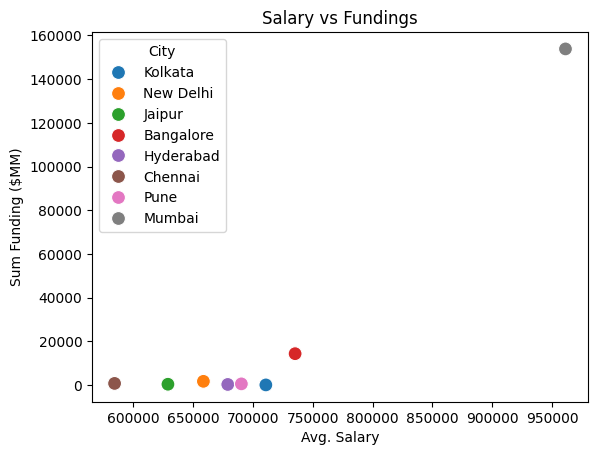

In [19]:
fig = sns.scatterplot(sps_fnd_loc,
                      x='Avg. Salary',
                      y='Sum Funding ($MM)',
                      hue='City',
                      s=100
                      ).set(title="Salary vs Fundings")

*ANSWER:*
Mumbai stands out the most in terms of total funding earned and average salary